In [2]:
import numpy as np
import matplotlib.pylab as plt

def step_fun(x): # 阶跃函数
    if x > 0:
        return 1
    else:
        return 0

In [3]:
import cvxpy as cp
import numpy as np
n = 3
m = 2
A = np.array([[1, 2, 3], [4, 5,6]])
y = np.array([6,30])
ε = 0.1
x = cp.Variable(n)
t = cp.Variable(n)
objective = cp.Minimize(cp.sum(t))
constraints = [ -t <= x, x <= t, cp.norm(A @ x - y) <= ε ]
prob = cp.Problem(objective, constraints)
prob.solve()
print("Optimal value:", prob.value)
print("Optimal x:", x.value)
def MLP(x):
    return 1 if x > 0 else 0


Optimal value: 9.820494558985075
Optimal x: [ 8.88858589e+00 -1.02878454e-08 -9.31908690e-01]


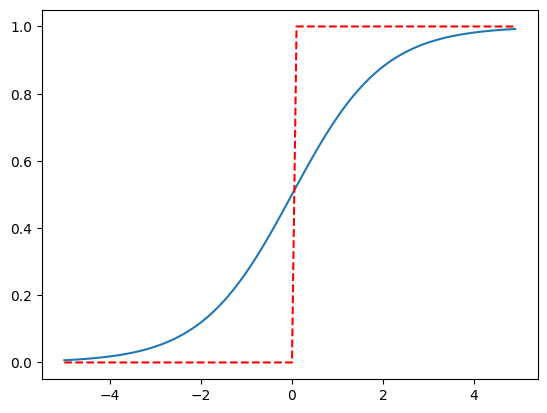

In [13]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def step_fun(x):
    return np.where(x>0,1,0) # numpy的三目运算符
X=np.arange(-5,5,0.1)
Y1=sigmoid(X)
Y2=step_fun(X)
plt.plot(X,Y1)
plt.plot(X,Y2,'--',color='r')

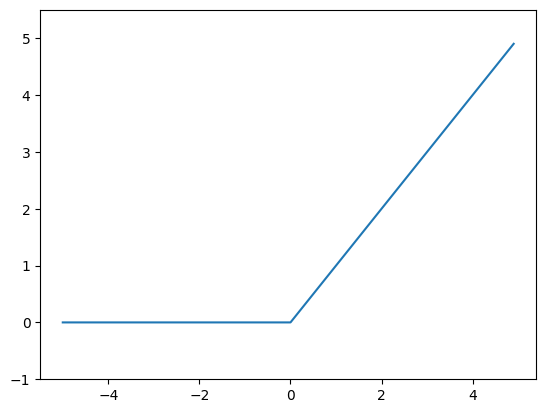

In [12]:
import numpy as np
import matplotlib.pylab as plt


def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-1.0, 5.5)
plt.show()

In [6]:
import sys,os
sys.path.append(os.pardir)
from dataset.mnist import load_mnist
from PIL import Image
import numpy as np
def image_show(img):
    pil_img=Image.fromarray(np.uint8(img))
    pil_img.show()
(x_train,t_train),(x_test,t_test)=load_mnist(flatten=True,normalize=False)
print(x_train.shape)
img=x_train[3]
label=t_train[3]
print(label)
img=img.reshape(28,28)
image_show(img)


(60000, 784)
1


In [15]:
def softmax(a):
    exp_a=np.exp(a)
    sum_exp_a=np.sum(exp_a)
    y=exp_a/sum_exp_a
    return y

# 手写数字神经网络推理
1. 输入层有784个神经元，因为图像大小28*28=784，输出10个，代表0~9
2. 设置三层神经网络实现，两个隐藏层，分别有50个和100个神经元一个输入和一个输出，

In [17]:
import pickle
def get_data():
    (x_train,t_train),(x_test,t_test) = \
    load_mnist(flatten=True,normalize=True,one_hot_label=False)
    return x_train,t_train
def init_network():
    with open("sample_weight.pkl",'rb') as f:
        network=pickle.load(f)
    return network

def predict(network,x):
    W1,W2,W3=network['W1'],network['W2'],network['W3']
    b1,b2,b3=network['b1'],network['b2'],network['b3']
    a1=np.dot(x,W1)+b1
    z1=sigmoid(a1)
    a2=np.dot(z1,W2)+b2
    z2=sigmoid(a2)
    a3=np.dot(z2,W3)+b3
    y=softmax(a3)
    return y
x,t=get_data()
network=init_network()
accuracy_cnt=0
for i in range(len(x)):
    y=predict(network,x[i])
    p=np.argmax(y)# 最高概率的索引
    if p==t[i]:
        accuracy_cnt+=1

print(accuracy_cnt/len(x))
    

0.9357666666666666
